
# 07 Chirps, Pulse Compression, and Range Resolution

## Purpose

This notebook introduces chirped pulses as a practical way to combine long pulse duration with fine range resolution. The goal is to connect the time-of-flight ideas from Notebook 06 to the waveform-design idea that bandwidth, not just duration, controls how sharply two echoes can be separated.

## Prerequisites

- Notebook 03: Fourier Transform and Spectral Intuition
- Notebook 04: Convolution, Filtering, and Matched Filters
- Notebook 05: Noise, Detection, and Estimation
- Notebook 06: Sonar Basics, Propagation, and Time of Flight

## Learning Objectives

By the end of this notebook, you should be able to:

- explain what a chirp is and how its frequency changes over time,
- explain why matched filtering compresses a long chirp into a narrow peak,
- connect pulse bandwidth to range resolution,
- interpret why a wider-band chirp can separate closer targets,
- and describe the main tradeoff between pulse duration, energy, bandwidth, and sidelobes.



## New Terms In This Notebook

- **Chirp**: a signal whose instantaneous frequency changes over time.
- **Instantaneous frequency**: the local oscillation rate of a signal at a given moment in time.
- **Linear frequency modulated (LFM) chirp**: a chirp whose instantaneous frequency changes linearly with time.
- **Complex baseband**: a complex-valued representation that keeps track of amplitude and phase in a simpler form, without needing to write the full rapidly oscillating real waveform explicitly.
- **Bandwidth**: the span of frequencies occupied by the signal.
- **Sweep rate**: the rate at which chirp frequency changes over time.
- **Uncoded pulse**: a plain pulse without an intentional internal frequency sweep or other embedded modulation pattern.
- **Pulse compression**: the process of transmitting a longer coded pulse and using matched filtering to produce a narrower response peak.
- **Compressed pulse**: the narrow matched-filter output peak produced by a coded pulse such as a chirp.
- **Range resolution**: the smallest separation in range for which two targets can be distinguished as separate echoes.
- **Time-bandwidth product**: the product of pulse duration and bandwidth, often used as a rough measure of chirp compression gain.
- **Sidelobe**: a smaller matched-filter response peak away from the main peak.



## Big Picture

Notebook 06 treated echoes as delayed copies of a transmitted pulse and showed that delay maps to range. This notebook asks the next design question: what transmit waveform gives us a sharp delay estimate without forcing us to transmit only a very short pulse?

The big idea is that chirps let us spread energy over a longer pulse duration while still obtaining a narrow matched-filter peak. That is the core pulse-compression idea used throughout practical radar and sonar systems.


## Mathematical Definitions and Relevant Intuition

### Linear Chirp Model

A simple complex baseband linear chirp of duration $T$ can be written as

$$
s(t) = \exp\left(j 2\pi \left(f_0 t + \tfrac{1}{2} k t^2\right)\right), \qquad 0 \le t < T,
$$

where $f_0$ is the starting frequency and $k$ is the sweep rate.

If the chirp starts at frequency $f_0$ and ends at frequency $f_1$, then the bandwidth is the frequency span

$$
B = f_1 - f_0,
$$

measured in hertz (Hz). If that sweep happens during duration $T$, then the sweep rate is

$$
k = \frac{B}{T}.
$$

The corresponding instantaneous frequency is

$$
f_{inst}(t) = f_0 + kt.
$$

That is why the oscillations get faster or slower as time advances. The phase is quadratic in time, but the instantaneous frequency changes linearly. This is the standard linear-chirp model summarized in the [Linear section of the Wikipedia Chirp article](https://en.wikipedia.org/wiki/Chirp#Linear).

### Matched Filter And Pulse Compression

If we match-filter a received echo using

$$
h_{MF}[n] = s^*[-n],
$$

then a delayed copy of the chirp produces a narrow peak in the output. The transmitted pulse may be long in time, but the matched-filter response is much sharper because different parts of the chirp align coherently only near the correct delay. The time-reversed conjugate construction is the standard matched-filter form described in the [Wikipedia Matched Filter article](https://en.wikipedia.org/wiki/Matched_filter).

### Bandwidth And Range Resolution

For a simple monostatic active-sonar picture, a common bandwidth-based approximation for range resolution $\Delta R$ is

$$
\Delta R \approx \frac{c}{2B},
$$

where $\Delta R$ is range resolution, $c$ is propagation speed, and $B$ is transmitted bandwidth.

This approximation says that larger bandwidth gives finer range resolution. The factor of 2 appears again because the measured delay is a two-way delay. This bandwidth-to-resolution relationship is summarized well in [ScienceDirect Topics: Range Resolution](https://www.sciencedirect.com/topics/computer-science/range-resolution).

### Why Chirps Matter

A short uncoded pulse, meaning a plain pulse without an intentional internal modulation pattern, can give good range resolution, but it may contain little energy. A long plain pulse can contain more energy, but by itself it produces a broader delay response, so the echo arrival time is less sharply localized. Chirps help because they allow a long transmission interval and wide bandwidth at the same time. Matched filtering then turns that long coded pulse into a narrow delay estimate. This is the pulse-compression motivation described in the [Pulse Compression overview](https://www.sciencedirect.com/topics/engineering/pulse-compression).


In [1]:

import matplotlib.pyplot as plt
import numpy as np

from _bootstrap import bootstrap_src_path

bootstrap_src_path()

from sonar_py_lib.dsp import matched_filter, normalize, time_axis
from sonar_py_lib.notebook_utils import set_plot_style
from sonar_py_lib.plotting import make_figure, plot_signal

set_plot_style()


def linear_chirp(duration_s: float, sample_rate_hz: float, start_freq_hz: float, bandwidth_hz: float) -> tuple[np.ndarray, np.ndarray]:
    num_samples = int(round(duration_s * sample_rate_hz))
    t = time_axis(num_samples, sample_rate_hz)
    sweep_rate = bandwidth_hz / duration_s
    phase = 2.0 * np.pi * (start_freq_hz * t + 0.5 * sweep_rate * t**2)
    return t, np.exp(1j * phase)


def fft_mag_db(x: np.ndarray, fs: float) -> tuple[np.ndarray, np.ndarray]:
    spec = np.fft.rfft(x)
    freqs = np.fft.rfftfreq(len(x), d=1.0 / fs)
    mag = np.abs(spec)
    mag = mag / np.max(mag)
    mag_db = 20.0 * np.log10(np.maximum(mag, 1e-6))
    return freqs, mag_db


def place_echo(record: np.ndarray, pulse: np.ndarray, start_idx: int, amplitude: float = 1.0) -> np.ndarray:
    out = np.array(record, dtype=complex, copy=True)
    stop_idx = min(len(out), start_idx + len(pulse))
    usable = stop_idx - start_idx
    if usable > 0:
        out[start_idx:stop_idx] += amplitude * pulse[:usable]
    return out



## Assumptions

- We use simple linear chirps rather than more advanced coding families.
- We use a constant propagation speed and a monostatic active-sonar picture.
- We focus on matched-filter magnitude rather than detailed sidelobe theory.
- We use idealized echoes without multipath or Doppler in this first notebook.



## A Chirp Spreads One Pulse Across Many Frequencies

The first figure is meant to show what changes when we replace a constant-frequency pulse with a chirp of the same duration. The top row shows the time-domain waveforms, and the bottom row shows their spectra.

The key thing to notice is that the chirp still occupies one pulse interval in time, but it spreads energy across a broader frequency span. That broader bandwidth is what later allows a sharper matched-filter peak.


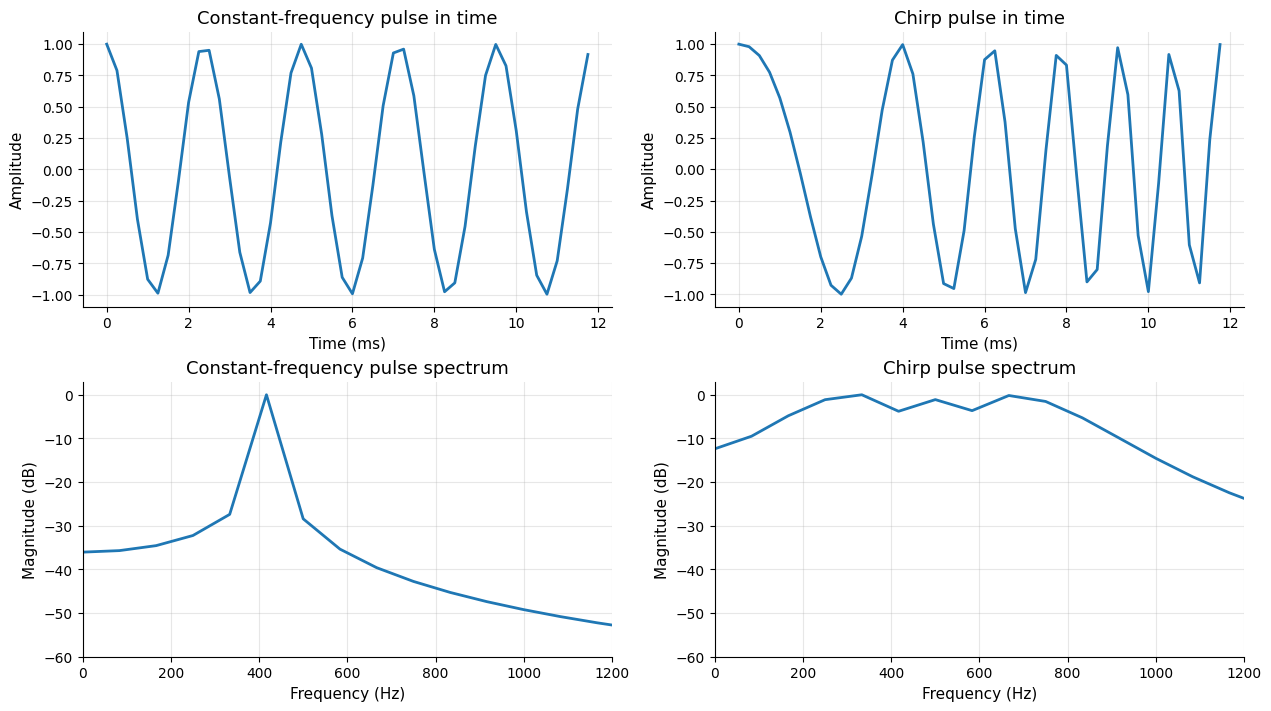

Pulse duration: 12.0 ms
Example chirp: start 120 Hz, bandwidth 800 Hz


In [2]:

fs = 4000.0
duration_s = 0.012
t_short, chirp_sig = linear_chirp(duration_s, fs, start_freq_hz=120.0, bandwidth_hz=800.0)
const_sig = np.cos(2.0 * np.pi * 420.0 * t_short)
chirp_real = np.real(chirp_sig)

freq_const, mag_const = fft_mag_db(const_sig, fs)
freq_chirp, mag_chirp = fft_mag_db(chirp_real, fs)

fig, axes = make_figure(nrows=2, ncols=2, figsize=(12.6, 7.0), sharex=False)
plot_signal(t_short * 1000.0, const_sig, ax=axes[0, 0], title='Constant-frequency pulse in time', xlabel='Time (ms)', ylabel='Amplitude')
plot_signal(t_short * 1000.0, chirp_real, ax=axes[0, 1], title='Chirp pulse in time', xlabel='Time (ms)', ylabel='Amplitude')
plot_signal(freq_const, mag_const, ax=axes[1, 0], title='Constant-frequency pulse spectrum', xlabel='Frequency (Hz)', ylabel='Magnitude (dB)')
plot_signal(freq_chirp, mag_chirp, ax=axes[1, 1], title='Chirp pulse spectrum', xlabel='Frequency (Hz)', ylabel='Magnitude (dB)')
axes[1, 0].set_ylim(-60, 3)
axes[1, 1].set_ylim(-60, 3)
axes[1, 0].set_xlim(0, 1200)
axes[1, 1].set_xlim(0, 1200)
plt.show()

print(f'Pulse duration: {1000.0 * duration_s:.1f} ms')
print('Example chirp: start 120 Hz, bandwidth 800 Hz')



The constant-frequency pulse concentrates most of its energy near one frequency. The chirp instead occupies a wider band because its instantaneous frequency changes during the pulse. In this notebook, bandwidth $B$ means the total frequency span of that sweep, measured in hertz.

That wider band is the important feature for the rest of the notebook. The chirp is not useful just because it “looks different” in time. It is useful because it gives the matched filter a broader frequency fingerprint to work with.



## Matched Filtering Compresses A Long Chirp

The next figure is meant to show the pulse-compression idea directly. We place one echo in a receive record and compare the matched-filter outputs of a constant-frequency pulse and a chirp of the same duration.

The key lesson is that the chirp can remain long in the transmit record while still producing a sharper matched-filter peak. That sharper peak is what makes delay estimation easier. This is exactly the pulse-compression idea discussed in the [Pulse Compression overview](https://www.sciencedirect.com/topics/engineering/pulse-compression).


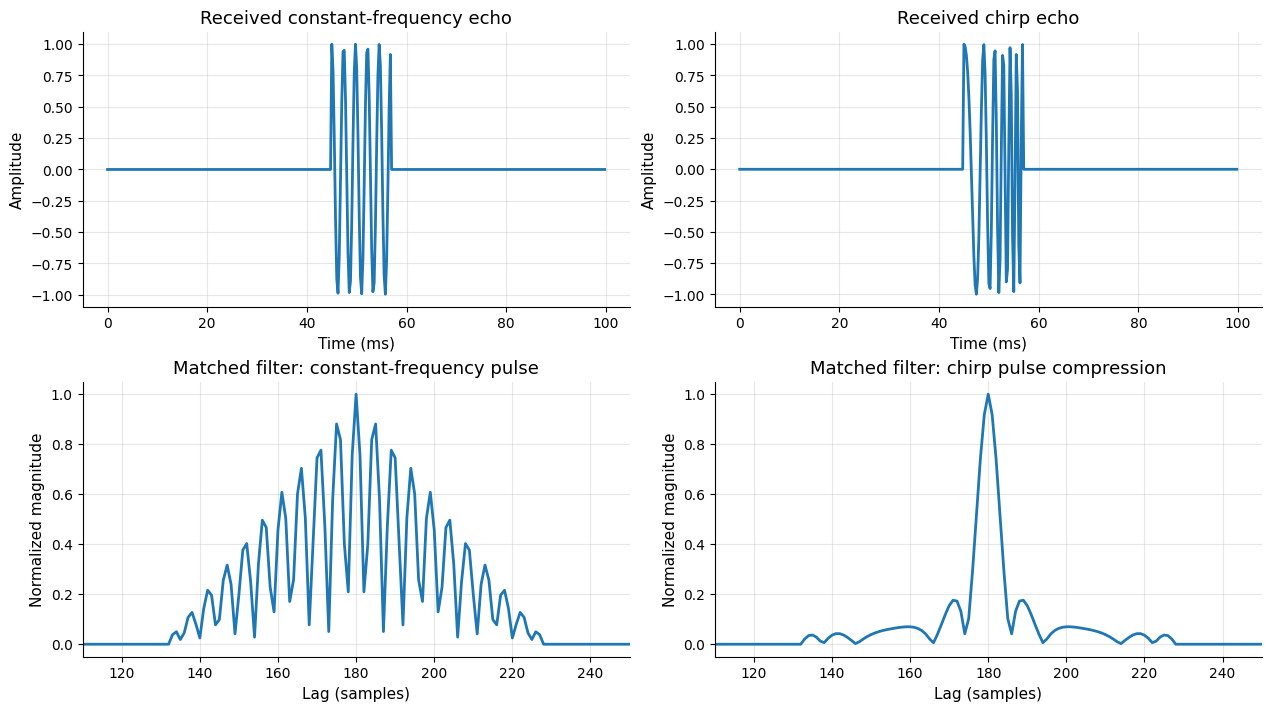

Echo inserted at sample 180


In [3]:

record_duration_s = 0.10
num_samples = int(round(record_duration_s * fs))
t_record = time_axis(num_samples, fs)
record_tone = np.zeros(num_samples, dtype=complex)
record_chirp = np.zeros(num_samples, dtype=complex)
start_idx = 180
record_tone = place_echo(record_tone, const_sig.astype(complex), start_idx)
record_chirp = place_echo(record_chirp, chirp_sig, start_idx)

mf_tone = matched_filter(record_tone, const_sig.astype(complex), mode='full')
mf_chirp = matched_filter(record_chirp, chirp_sig, mode='full')
lags = np.arange(-(len(const_sig) - 1), len(record_tone))

fig, axes = make_figure(nrows=2, ncols=2, figsize=(12.6, 7.0), sharex=False)
plot_signal(t_record * 1000.0, np.real(record_tone), ax=axes[0, 0], title='Received constant-frequency echo', xlabel='Time (ms)', ylabel='Amplitude')
plot_signal(t_record * 1000.0, np.real(record_chirp), ax=axes[0, 1], title='Received chirp echo', xlabel='Time (ms)', ylabel='Amplitude')
plot_signal(lags, normalize(np.abs(mf_tone)), ax=axes[1, 0], title='Matched filter: constant-frequency pulse', xlabel='Lag (samples)', ylabel='Normalized magnitude')
plot_signal(lags, normalize(np.abs(mf_chirp)), ax=axes[1, 1], title='Matched filter: chirp pulse compression', xlabel='Lag (samples)', ylabel='Normalized magnitude')
for ax in axes[1, :]:
    ax.set_xlim(start_idx - 70, start_idx + 70)
plt.show()

print(f'Echo inserted at sample {start_idx}')



Both received records contain echoes with the same overall duration, but the matched-filter outputs are not equally sharp. The chirp response is more localized because the full sweep pattern aligns coherently only near the correct delay.

This is the pulse-compression idea in one picture: transmit long enough to carry useful energy, then recover a narrow timing peak with the matched filter.



## Bandwidth Controls Range Resolution

The final figure is meant to show why bandwidth matters for resolving two nearby targets. We simulate two chirp echoes with the same pulse duration but compare a narrow-band chirp against a wide-band chirp.

The main things to watch are the dotted lines marking the two true target ranges and whether the matched-filter output forms one blended hump or two distinguishable peaks. The wider-band chirp should separate the targets more clearly. This is the practical content behind the standard bandwidth-to-resolution relationship summarized in [ScienceDirect Topics: Range Resolution](https://www.sciencedirect.com/topics/computer-science/range-resolution).


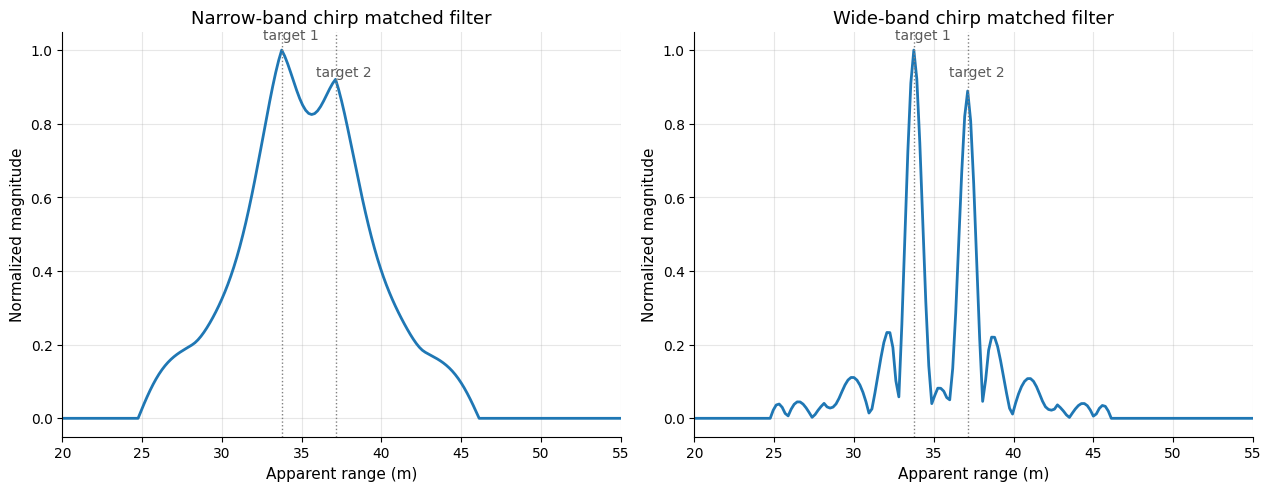

Target separation: 3.38 m
Approx. narrow-band resolution from bandwidth: 3.75 m
Approx. wide-band resolution from bandwidth: 0.94 m


In [4]:

c_sound = 1500.0
pulse_duration_s = 0.012
_, chirp_narrow = linear_chirp(pulse_duration_s, fs, start_freq_hz=180.0, bandwidth_hz=200.0)
_, chirp_wide = linear_chirp(pulse_duration_s, fs, start_freq_hz=180.0, bandwidth_hz=800.0)

record_len = int(round(0.12 * fs))
record_narrow = np.zeros(record_len, dtype=complex)
record_wide = np.zeros(record_len, dtype=complex)
first_idx = 180
separation_samples = 18
record_narrow = place_echo(record_narrow, chirp_narrow, first_idx, amplitude=1.0)
record_narrow = place_echo(record_narrow, chirp_narrow, first_idx + separation_samples, amplitude=0.9)
record_wide = place_echo(record_wide, chirp_wide, first_idx, amplitude=1.0)
record_wide = place_echo(record_wide, chirp_wide, first_idx + separation_samples, amplitude=0.9)

mf_narrow = matched_filter(record_narrow, chirp_narrow, mode='full')
mf_wide = matched_filter(record_wide, chirp_wide, mode='full')
lags_res = np.arange(-(len(chirp_narrow) - 1), len(record_narrow))
range_axis_m = 0.5 * c_sound * (lags_res / fs)
true_r1_m = 0.5 * c_sound * (first_idx / fs)
true_r2_m = 0.5 * c_sound * ((first_idx + separation_samples) / fs)
true_sep_m = true_r2_m - true_r1_m
res_narrow_m = c_sound / (2.0 * 200.0)
res_wide_m = c_sound / (2.0 * 800.0)

fig, axes = make_figure(nrows=1, ncols=2, figsize=(12.6, 4.8), sharex=False)
plot_signal(range_axis_m, normalize(np.abs(mf_narrow)), ax=axes[0], title='Narrow-band chirp matched filter', xlabel='Apparent range (m)', ylabel='Normalized magnitude')
plot_signal(range_axis_m, normalize(np.abs(mf_wide)), ax=axes[1], title='Wide-band chirp matched filter', xlabel='Apparent range (m)', ylabel='Normalized magnitude')
for ax in axes:
    ax.set_xlim(20, 55)
    ax.axvline(true_r1_m, color='0.5', linestyle=':', linewidth=1.0)
    ax.axvline(true_r2_m, color='0.5', linestyle=':', linewidth=1.0)
    ax.text(true_r1_m - 1.2, 1.03, 'target 1', color='0.35')
    ax.text(true_r2_m - 1.2, 0.93, 'target 2', color='0.35')
plt.show()

print(f'Target separation: {true_sep_m:.2f} m')
print(f'Approx. narrow-band resolution from bandwidth: {res_narrow_m:.2f} m')
print(f'Approx. wide-band resolution from bandwidth: {res_wide_m:.2f} m')


The narrow-band chirp has a broader matched-filter response, so the two targets blend together more strongly. The wide-band chirp produces a tighter response, so the same two targets are easier to separate.

That is the practical meaning of the approximation for range resolution, $\Delta R \approx c / (2B)$: larger bandwidth makes two nearby ranges easier to distinguish.



## Tradeoffs And Limitations

Several important tradeoffs already appear in this first chirp notebook:

- Larger bandwidth improves range resolution but can increase system complexity and sampling demands.
- Longer pulse duration can increase transmitted energy, but the matched filter is needed to avoid a blurred delay estimate.
- Pulse compression creates a narrow main peak, but sidelobes can still make weak nearby targets harder to interpret.
- Ideal chirps and ideal echoes are easy to illustrate, but real propagation can include Doppler, distortion, multipath, and model mismatch.


## References

- [Wikipedia Chirp article](https://en.wikipedia.org/wiki/Chirp)
- [Wikipedia Matched Filter article](https://en.wikipedia.org/wiki/Matched_filter)
- [ScienceDirect Topics: Pulse Compression](https://www.sciencedirect.com/topics/engineering/pulse-compression)
- [ScienceDirect Topics: Range Resolution](https://www.sciencedirect.com/topics/computer-science/range-resolution)



## Suggested Next Questions

- What changes when the received record contains echoes from several targets instead of one?
- How should we model a target scene as a sum of delayed, scaled returns?
- How does overlap appear when multiple echoes occupy the same time region?

The next notebook turns to target scene modeling and echo synthesis.



## Suggested Next Questions

- What changes when the received record contains echoes from several targets instead of one?
- How should we model a target scene as a sum of delayed, scaled returns?
- How does overlap appear when multiple echoes occupy the same time region?

The next notebook turns to target scene modeling and echo synthesis.
